In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import shap
from tools import plot_shap_summary_bar, to_subscript

# These are the experimental results that I provided for: 
"Identifying Deformation Drivers in Dam Segments Using Combined X- and Cm-Band PS Time Series"


Here we displaying results in three ways: Shapley values, Residual comparison and model parameters. (Only the first is in the paper.)


Importantly, we ran a grid seach first via glör_paper_hydra.py to evaluate various regression models. Only the most expressive models (inter) are used in the paper.

In [51]:
res = {}

# Load model results

for ps in ["t+s", "S1", "tsx"]:
    m1 = pickle.load(open(f"results/{ps}/drain.p", "rb"))
    m2 = pickle.load(open(f"results/{ps}/refill_T.p", "rb"))
    m3 = pickle.load(open(f"results/{ps}/full_T.p", "rb"))
    m4 = pickle.load(open(f"results/{ps}/refill_W.p", "rb"))
    m5 = pickle.load(open(f"results/{ps}/full_W.p", "rb"))
    m6 = pickle.load(open(f"results/{ps}/refill.p", "rb"))
    m7 = pickle.load(open(f"results/{ps}/full.p", "rb"))
    m8 = pickle.load(open(f"results/{ps}/refill_inter.p", "rb"))
    m9 = pickle.load(open(f"results/{ps}/full_inter.p", "rb"))
    res[ps] = [m1, m2, m3, m4, m5, m6, m7, m8, m9]

# Shapely values for the two sections

['T_0', 'T_1', 'W_0', 'W_1', 'inter_0', 'inter_1', 'W_diff', 'T_diff', 'const', 'trend']
['Tₜ', 'Tₜ₁', 'Wₜ', 'Wₜ₁', 'Tₜ*Wₜ', 'Tₜ₁*Wₜ₁', 'Wₜ-Wₜ₁', 'Tₜ-Tₜ₁', 'Con', 'Trₜ', 'Const']
['T_0', 'T_1', 'W_0', 'W_1', 'inter_0', 'inter_1', 'W_diff', 'T_diff', 'const', 'trend']


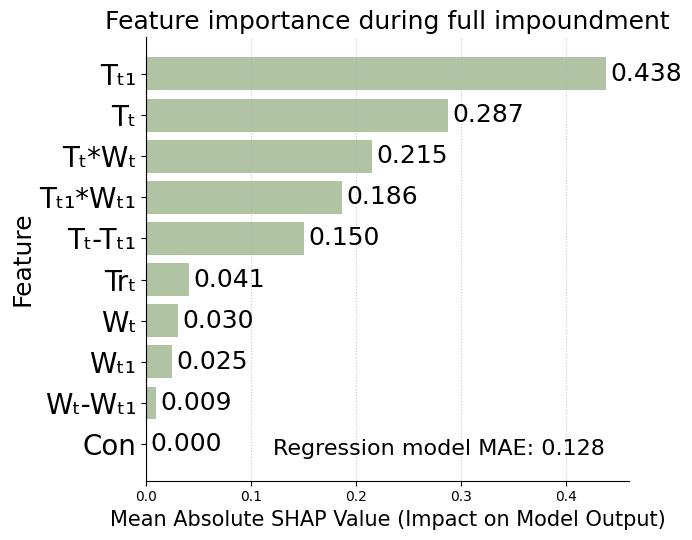

In [52]:
# a 
X = pd.read_csv("data_saves/temporaryfull_inter.csv", index_col=0)
X10 = shap.utils.sample(X, 100)  # 100 instance
# compute the SHAP values for the linear model
explainer = shap.Explainer(res["t+s"][-1].predict, X10)
shap_values = explainer(X)
[subscripted := [to_subscript(f) for f in ["Tt","Tt1","Wt","Wt1", "Tt*Wt", "Tt1*Wt1", "Wt-Wt1","Tt-Tt1","Con", "Trt"]]]
print(shap_values.feature_names)
print(subscripted + ["Const"])
plot_shap_summary_bar(shap_values.abs.mean(0).values,subscripted , title="Feature importance during full impoundment")
plt.text(
    0.95, 0.05, "Regression model MAE: 0.128",
    fontsize=16, color="black", ha="right", va="bottom",
    transform=plt.gca().transAxes
)
print(shap_values.feature_names)
plt.savefig("../imgs/shap_waterfall_full_inter.pdf", bbox_inches="tight")

['T_0', 'T_1', 'W_0', 'W_1', 'inter_0', 'inter_1', 'W_diff', 'T_diff', 'const', 'trend']
['Tₜ', 'Tₜ₁', 'Wₜ', 'Wₜ₁', 'Tₜ*Wₜ', 'Tₜ₁*Wₜ₁', 'Wₜ-Wₜ₁', 'Tₜ-Tₜ₁', 'Con', 'Trₜ', 'Const']
['T_0', 'T_1', 'W_0', 'W_1', 'inter_0', 'inter_1', 'W_diff', 'T_diff', 'const', 'trend']


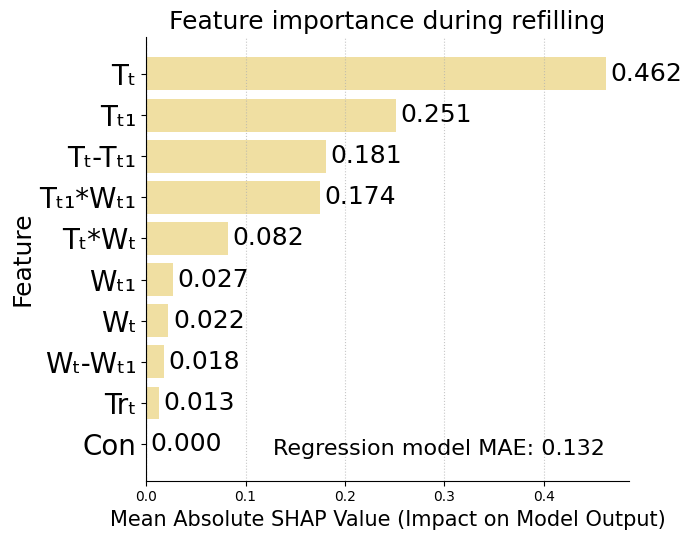

In [53]:
# a classic housing price dataset
X = pd.read_csv("data_saves/temporaryrefill_inter.csv", index_col=0)
X10 = shap.utils.sample(X, 100)  # 100 instance
# compute the SHAP values for the linear model
explainer = shap.Explainer(res["t+s"][-2].predict, X10)
shap_values = explainer(X)
[subscripted := [to_subscript(f) for f in ["Tt","Tt1","Wt","Wt1", "Tt*Wt", "Tt1*Wt1","Wt-Wt1","Tt-Tt1","Con", "Trt"]]]
print(shap_values.feature_names)
print(subscripted + ["Const"])
plot_shap_summary_bar(shap_values.abs.mean(0).values,subscripted, title="Feature importance during refilling", new=True)
print(shap_values.feature_names)
plt.text(
    0.95, 0.05, "Regression model MAE: 0.132",
    fontsize=16, color="black", ha="right", va="bottom",
    transform=plt.gca().transAxes
)
plt.savefig("../imgs/shap_waterfall_refill_inter.pdf", bbox_inches="tight")

# Additional ananlysis that was not used in the paper.



## Residual comparison


Here we simply compare how much difference in Residuals we can achieve by including specific terms

Note: You have to generate the results for all PS time series first via glör_paper_hydra.py

In [39]:

data = {
    "Full(t+s)": [
        res["t+s"][8].resid.abs().mean(),
        res["t+s"][6].resid.abs().mean(),
        res["t+s"][4].resid.abs().mean(),
        res["t+s"][2].resid.abs().mean()
    ],
    "Full (S1)": [
        res["S1"][8].resid.abs().mean(),
        res["S1"][6].resid.abs().mean(),
        res["S1"][4].resid.abs().mean(),
        res["S1"][2].resid.abs().mean()
    ],
    "Full (tsx)": [
        res["tsx"][8].resid.abs().mean(),
        res["tsx"][6].resid.abs().mean(),
        res["tsx"][4].resid.abs().mean(),
        res["tsx"][2].resid.abs().mean()
    ],
    "Filling(t+s)": [
        res["t+s"][7].resid.abs().mean(),
        res["t+s"][5].resid.abs().mean(),
        res["t+s"][3].resid.abs().mean(),
        res["t+s"][1].resid.abs().mean()
    ],
    "Filling(S1)": [
        res["S1"][7].resid.abs().mean(),
        res["S1"][5].resid.abs().mean(),
        res["S1"][3].resid.abs().mean(),
        res["S1"][1].resid.abs().mean()
    ],
    "Filling(tsx)": [
        res["tsx"][7].resid.abs().mean(),
        res["tsx"][5].resid.abs().mean(),
        res["tsx"][3].resid.abs().mean(),
        res["tsx"][1].resid.abs().mean()
    ],
    "Empty (t+s)": [
        res["t+s"][0].resid.abs().mean()
     ],
    "Empty (S1)": [
        None, None, None,res["S1"][0].resid.abs().mean()
    ],
    "Empty (tsx)": [
        None, None, None,res["tsx"][0].resid.abs().mean()
    ],


}

In [40]:
# Example comparison of residuals

df_resid = pd.DataFrame(data["Full(t+s)"], columns=["W*T"]).T
df_resid.index.name = "Full"
df_resid = df_resid.round(3)

df_resid = df_resid.T.astype(str)

df_resid = df_resid.replace("nan", "-")

In [41]:
print(df_resid.to_latex())

\begin{tabular}{ll}
\toprule
Full & W*T \\
\midrule
0 & 0.128 \\
1 & 0.131 \\
2 & 0.15 \\
3 & 0.132 \\
\bottomrule
\end{tabular}



## Model comparison: 

model parameters can be compared between models in the following manner.

In [42]:
print(res["t+s"][0].summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
T_0            0.4913      0.080      6.154      0.000       0.332       0.651
const          0.1463      0.051      2.880      0.005       0.045       0.248
trend          0.3096      0.080      3.855      0.000       0.149       0.470


In [43]:
print(res["t+s"][7].summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
T_0            2.3964      1.402      1.709      0.092      -0.397       5.190
T_1           -1.2833      1.344     -0.955      0.343      -3.960       1.393
W_0            0.2164      0.102      2.119      0.037       0.013       0.420
W_1            0.2599      0.111      2.338      0.022       0.038       0.481
inter_0        0.4885      0.224      2.178      0.033       0.042       0.935
inter_1       -0.9899      0.257     -3.854      0.000      -1.501      -0.478
W_diff         0.2001      0.145      1.381      0.171      -0.088       0.489
T_diff         1.3412      0.735      1.825      0.072      -0.123       2.805
const         -0.7560      0.415     -1.820      0.073      -1.583       0.071
trend          0.0528      0.086      0.616      0.540      -0.118       0.223


In [44]:
print(res["t+s"][8].summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
T_0           -1.4220      4.104     -0.346      0.730      -9.586       6.742
T_1            2.1804      4.166      0.523      0.602      -6.108      10.468
W_0            0.1958      0.112      1.746      0.084      -0.027       0.419
W_1            0.1544      0.121      1.281      0.204      -0.085       0.394
inter_0       -1.6817      1.261     -1.334      0.186      -4.190       0.826
inter_1        1.4714      1.326      1.110      0.270      -1.166       4.109
W_diff        -0.1093      0.161     -0.678      0.500      -0.430       0.211
T_diff        -1.2206      1.714     -0.712      0.478      -4.630       2.189
const          0.4229      0.590      0.717      0.476      -0.751       1.597
trend          0.1624      0.077      2.118      0.037       0.010       0.315
